# Objectifs d'apprentissage – Semaine 4

À l'issue de cette semaine, l'étudiant sera capable de :

- **Manipuler** les signaux à temps discret (séquences) et leurs opérations de base.
- **Définir** un système linéaire invariant dans le temps (LTI) et ses propriétés.
- **Calculer** la convolution discrète de deux séquences (manuellement et avec Python).
- **Interpréter** la convolution comme la réponse d'un système LTI.
- **Implémenter** un filtre moyenneur (moyenne mobile) et analyser son effet.
- **Relier** la convolution à la réponse impulsionnelle et à la stabilité/causalité.

# 1. Rappels théoriques

## 1.1 Signaux à temps discret
Un signal discret est une séquence de nombres $x[n]$, où $n$ est un entier (indice temporel).

**Signaux élémentaires** :
- Impulsion unité : $\delta[n] = \begin{cases} 1 & n=0 \\ 0 & \text{sinon} \end{cases}$
- Échelon unité : $u[n] = \begin{cases} 1 & n \ge 0 \\ 0 & n < 0 \end{cases}$
- Exponentielle : $x[n] = a^n u[n]$ ou $x[n] = e^{j\omega n}$
- Sinusoïde : $x[n] = A\cos(\omega n + \phi)$

## 1.2 Systèmes LTI
Un système est **linéaire** si la superposition s'applique : $T\{a x_1 + b x_2\} = a T\{x_1\} + b T\{x_2\}$.
Il est **invariant dans le temps** si un décalage temporel de l'entrée produit le même décalage en sortie : $y[n-k] = T\{x[n-k]\}$.

## 1.3 Convolution
Pour un système LTI, la sortie $y[n]$ est donnée par la convolution de l'entrée $x[n]$ avec la réponse impulsionnelle $h[n]$ :
$$ y[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k] = (x * h)[n] $$

**Propriétés de la convolution** :
- Commutative : $x * h = h * x$
- Associative : $(x * h_1) * h_2 = x * (h_1 * h_2)$
- Distributive : $x * (h_1 + h_2) = x * h_1 + x * h_2$
- Élément neutre : $x * \delta = x$

## 1.4 Stabilité et causalité
- **Causalité** : un système LTI est causal si $h[n] = 0$ pour $n < 0$.
- **Stabilité** : un système LTI est stable (BIBO) si $\sum_{n} |h[n]| < \infty$.

---

# 2. Démonstration : convolution discrète en Python

Nous allons illustrer la convolution à l'aide de la fonction `np.convolve` de NumPy.

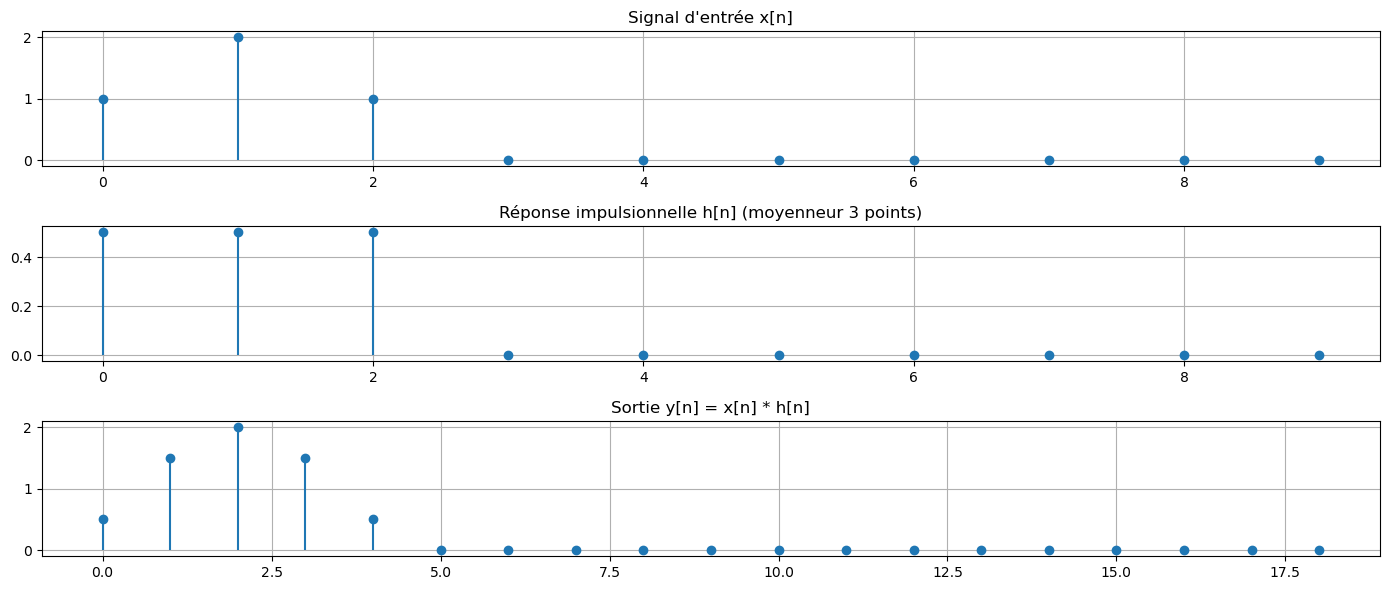

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Définir un signal x[n] et une réponse impulsionnelle h[n]
n = np.arange(0, 10)
x = np.array([1, 2, 1, 0, 0, 0, 0, 0, 0, 0])  # signal simple
h = np.array([0.5, 0.5, 0.5, 0, 0, 0, 0, 0, 0, 0])  # moyenneur sur 3 points

# Convolution
y = np.convolve(x, h, mode='full')  # 'full' donne la convolution complète
n_y = np.arange(len(y))

plt.figure(figsize=(14, 6))
plt.subplot(3, 1, 1)
plt.stem(n, x, basefmt=' ')
plt.title('Signal d\'entrée x[n]')
plt.grid()

plt.subplot(3, 1, 2)
plt.stem(n, h, basefmt=' ')
plt.title('Réponse impulsionnelle h[n] (moyenneur 3 points)')
plt.grid()

plt.subplot(3, 1, 3)
plt.stem(n_y, y, basefmt=' ')
plt.title('Sortie y[n] = x[n] * h[n]')
plt.grid()

plt.tight_layout()
plt.show()

# 3. Filtre moyenneur (Moving Average)

Un filtre moyenneur est un système LTI dont la réponse impulsionnelle est une fenêtre rectangulaire :
$$ h[n] = \frac{1}{M} \, (u[n] - u[n-M]) $$
C'est un filtre FIR (réponse impulsionnelle finie). Il réalise une moyenne glissante des $M$ derniers échantillons.

## 3.1 Effet sur un signal bruité

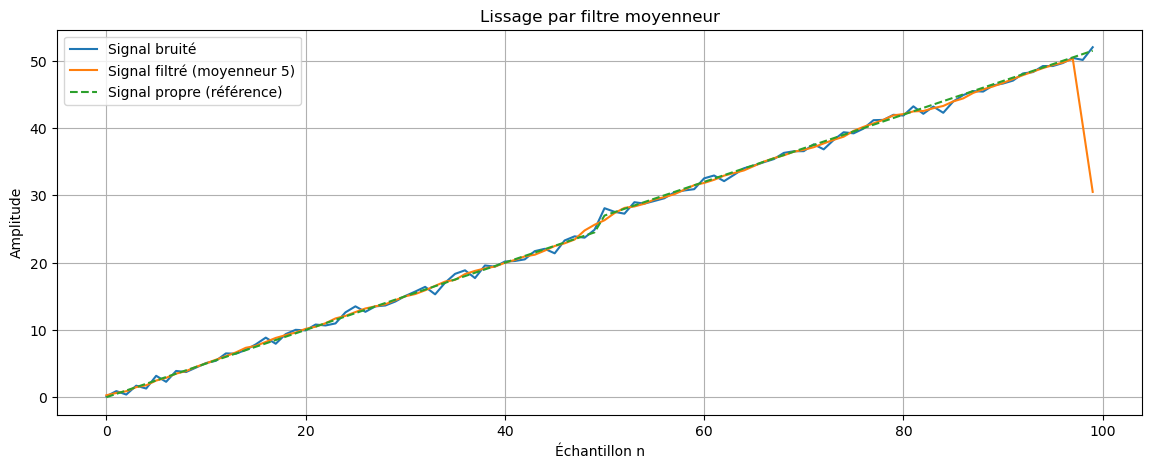

In [2]:
# Générer un signal bruité
N = 100
n = np.arange(N)
# Signal propre : une rampe + un échelon
x_propre = 0.5 * n + 2 * (n >= 50)
bruit = 0.5 * np.random.randn(N)
x = x_propre + bruit

# Filtre moyenneur de taille 5
M = 5
h = np.ones(M) / M
y = np.convolve(x, h, mode='same')

plt.figure(figsize=(14, 5))
plt.plot(n, x, label='Signal bruité')
plt.plot(n, y, label='Signal filtré (moyenneur 5)')
plt.plot(n, x_propre, '--', label='Signal propre (référence)')
plt.xlabel('Échantillon n')
plt.ylabel('Amplitude')
plt.title('Lissage par filtre moyenneur')
plt.grid()
plt.legend()
plt.show()

# 4. Exercices – Semaine 4 (niveau avancé)

## Thème 1 : Calculs de convolution

### Exercice 1 – Convolution manuelle
Soient les séquences $x[n] = \{1, 2, 1\}$ pour $n=0,1,2$ et $h[n] = \{1, -1, 1\}$ pour $n=0,1,2$.

1. Calculer manuellement la convolution $y[n] = x[n] * h[n]$.
2. Vérifier avec Python.
3. Déterminer la durée de $y[n]$.

**Correction** (à compléter) :

In [3]:
x = np.array([1, 2, 1])
h = np.array([1, -1, 1])
y = np.convolve(x, h)
print(f"y = {y}")
print(f"Durée de y : {len(y)} échantillons")

y = [1 1 0 1 1]
Durée de y : 5 échantillons


### Exercice 2 – Convolution avec des séquences infinies
Soit $x[n] = a^n u[n]$ avec $|a| < 1$ et $h[n] = b^n u[n]$ avec $|b| < 1$.

1. Calculer analytiquement $y[n] = x[n] * h[n]$ pour $a \neq b$.
2. Pour $a=0.5$, $b=0.3$, générer les séquences sur $n=0\ldots 30$ et comparer avec le résultat analytique.
3. Que se passe-t-il si $a = b$ ?

**Correction** (à compléter) :

Rappel : pour $a \neq b$, $y[n] = \frac{a^{n+1} - b^{n+1}}{a - b} u[n]$.

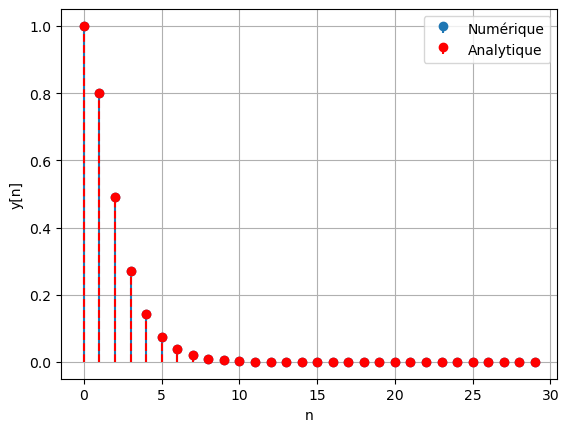

In [4]:
a, b = 0.5, 0.3
N = 30
n = np.arange(N)
x = a**n
h = b**n
y_num = np.convolve(x, h)[:N]  # on prend les N premiers

# Analytique
y_ana = (a**(n+1) - b**(n+1)) / (a - b)

plt.stem(n, y_num, basefmt=' ', label='Numérique')
plt.stem(n, y_ana, linefmt='r--', markerfmt='ro', basefmt=' ', label='Analytique')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.legend()
plt.grid()
plt.show()

### Exercice 3 – Stabilité et causalité
Pour chaque réponse impulsionnelle suivante, déterminer si le système est causal et/ou stable :

1. $h[n] = (0.5)^n u[n]$
2. $h[n] = 2^n u[-n-1]$
3. $h[n] = \delta[n] - 0.8 \delta[n-1] + 0.6 \delta[n-2]$
4. $h[n] = \cos(\pi n) u[n]$

Justifier chaque réponse.

**Réponses** :
1. Causal (h[n]=0 pour n<0) et stable ($\sum |h[n]| = \sum 0.5^n = 2 < \infty$).
2. Non causal (h[-1] ≠ 0) et instable ($\sum_{n=-\infty}^{-1} 2^{-n} = \infty$).
3. Causal (support fini non négatif) et stable (somme finie).
4. Causal (support non négatif) mais instable ($\sum |\cos(\pi n)|$ diverge).

## Thème 2 : Filtrage et convolution

### Exercice 4 – Filtre moyenneur et réponse fréquentielle
Un filtre moyenneur sur $M$ points a pour réponse impulsionnelle $h[n] = \frac{1}{M} (u[n] - u[n-M])$.

1. Montrer que sa réponse en fréquence $H(e^{j\omega})$ est $\frac{1}{M} \frac{\sin(\omega M/2)}{\sin(\omega/2)} e^{-j\omega(M-1)/2}$.
2. Pour $M=5$, tracer le module de $H(e^{j\omega})$ pour $\omega \in [-\pi, \pi]$.
3. À partir du tracé, déterminer la fréquence de coupure approximative (où le gain chute de 3 dB).

**Code** :

In [ ]:
M = 5
omega = np.linspace(-np.pi, np.pi, 500)
H = (1/M) * np.sin(omega*M/2) / np.sin(omega/2 + 1e-12) * np.exp(-1j*omega*(M-1)/2)
H_mod = np.abs(H)

plt.plot(omega, H_mod)
plt.xlabel('$\omega$ (rad)')
plt.ylabel('|H($\omega$)|')
plt.title('Réponse fréquentielle du moyenneur M=5')
plt.grid()
plt.show()

# Fréquence de coupure à -3 dB (gain ~0.707) : approximativement 0.4 rad/échantillon

### Exercice 5 – Convolution pour la détection d'écho
Un signal $x[n]$ est envoyé dans un canal qui produit un écho :
$$ y[n] = x[n] + \alpha x[n-D] $$

1. Exprimer la réponse impulsionnelle $h[n]$ du canal.
2. Pour $\alpha = 0.8$, $D=10$, simuler l'effet sur un signal $x[n]$ de votre choix (par exemple une impulsion ou un signal sinusoïdal).
3. Proposer une méthode pour annuler l'écho (inverse du canal).

**Code** :

In [ ]:
D = 10
alpha = 0.8
N = 50
x = np.zeros(N)
x[0] = 1  # impulsion

h = np.zeros(N)
h[0] = 1
h[D] = alpha

y = np.convolve(x, h)[:N]

plt.stem(np.arange(N), x, basefmt=' ', label='x[n]')
plt.stem(np.arange(N), y, basefmt=' ', linefmt='r-', markerfmt='ro', label='y[n] (avec écho)')
plt.legend()
plt.grid()
plt.show()

# Pour annuler l'écho, on peut utiliser un filtre inverse (si stable) ou un filtre adaptatif.

### Exercice 6 – Convolution et propriétés des systèmes LTI
Considérons deux systèmes LTI en cascade : $h_1[n] = \delta[n] - 0.5\delta[n-1]$ et $h_2[n] = \delta[n] + 0.5\delta[n-1]$.

1. Calculer la réponse impulsionnelle globale $h[n] = h_1[n] * h_2[n]$.
2. Que constatez-vous ? Ce système est-il l'identité ?
3. Généraliser : si $h_1[n] = \delta[n] - a\delta[n-1]$ et $h_2[n] = \delta[n] + a\delta[n-1]$, que vaut la convolution ?

**Code** :

In [ ]:
h1 = np.array([1, -0.5])
h2 = np.array([1, 0.5])
h = np.convolve(h1, h2)
print(f"h[n] = {h}")
# Résultat : [1, 0, -0.25]  -> ce n'est pas l'identité ! L'ordre de convolution donne un filtre du second ordre.

## Thème 3 : Synthèse et programmation

### Exercice 7 – Implémentation efficace d'un filtre moyenneur
Pour un filtre moyenneur de taille $M$, l'implémentation directe par convolution nécessite $O(NM)$ opérations.
Proposer une implémentation récursive (moyenne glissante) qui réduit la complexité à $O(N)$.

Écrire une fonction `moving_average(x, M)` qui implémente cette version efficace.
Tester avec un signal et comparer les temps d'exécution avec la version `np.convolve`.

In [5]:
def moving_average(x, M):
    """Filtre moyenneur récursif (efficace)."""
    y = np.zeros_like(x)
    acc = 0.0
    for n in range(len(x)):
        acc += x[n]
        if n >= M:
            acc -= x[n-M]
        y[n] = acc / M
    return y

# Test
x = np.random.randn(1000)
M = 10
y1 = moving_average(x, M)
y2 = np.convolve(x, np.ones(M)/M, mode='same')
print("Erreur max :", np.max(np.abs(y1 - y2)))

# Comparaison de temps (à décommenter pour tester)
# import time
# t1 = time.time(); moving_average(x, M); t1 = time.time()-t1
# t2 = time.time(); np.convolve(x, np.ones(M)/M, mode='same'); t2 = time.time()-t2
# print(f"Temps récursif : {t1:.5f}s, convolve : {t2:.5f}s")

Erreur max : 0.7729839277834524


### Exercice 8 – Réponse impulsionnelle d'un système récursif
Un système LTI est décrit par l'équation aux différences :
$$ y[n] - 0.5 y[n-1] = x[n] + 0.2 x[n-1] $$

1. Déterminer sa réponse impulsionnelle $h[n]$ pour un système causal (conditions initiales nulles).
2. Calculer les premiers termes de $h[n]$ (jusqu'à n=5) et vérifier avec Python.
3. Ce système est-il stable ? Justifier.

**Correction** :
On résout la récurrence : $h[n] - 0.5 h[n-1] = \delta[n] + 0.2 \delta[n-1]$.
Pour $n=0$ : $h[0] = 1$.
Pour $n=1$ : $h[1] - 0.5 h[0] = 0.2 \Rightarrow h[1] = 0.7$.
Pour $n\ge 2$ : $h[n] = 0.5 h[n-1]$.
Donc $h[n] = 0.7 (0.5)^{n-1}$ pour $n\ge 1$, et $h[0]=1$.
La série $\sum |h[n]|$ converge (car $0.5<1$), donc stable.

In [6]:
# Simulation Python
N = 10
h = np.zeros(N)
for n in range(N):
    if n == 0:
        h[n] = 1
    elif n == 1:
        h[n] = 0.5*h[0] + 0.2
    else:
        h[n] = 0.5*h[n-1]
print(f"h[n] = {h}")

# Vérification avec la fonction scipy.signal.lfilter
from scipy import signal
b = [1, 0.2]
a = [1, -0.5]
h_scipy = signal.lfilter(b, a, [1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
print(f"h_scipy = {h_scipy}")

h[n] = [1.         0.7        0.35       0.175      0.0875     0.04375
 0.021875   0.0109375  0.00546875 0.00273437]
h_scipy = [1.         0.7        0.35       0.175      0.0875     0.04375
 0.021875   0.0109375  0.00546875 0.00273437]


# 5. Livrable Semaine 4

- Remplir les cellules de code avec vos solutions.
- Répondre aux questions théoriques dans les cellules markdown.
- Inclure des commentaires explicatifs.
- Rendre le notebook complet (cellules exécutées).

**Date de rendu** : à définir par l'enseignant.

---